# 01 — Gaussian Process Surrogate (from scratch)
**Model:** Gaussian Process Regression — numpy only, no sklearn GP modules.

**Why GP for this dataset:**
Only 17 training points. GP gives exact interpolation at training points
plus calibrated uncertainty bands everywhere else.
Uncertainty comes from the mathematics of the model — not from sampling.

**Notebook role in pipeline:**
```
data_utils.py  →  01_gp_surrogate.ipynb  →  04_model_comparison.ipynb
                                          →  ../analysis/abaqus_material_cards.inp
```

**Outputs saved to** `../analysis/`:
- `tension_compression_asymmetry.png`
- `gp_predictions.png`
- `gp_loo_residuals.png`
- `gp_derived_quantities.png`
- `gp_results.pkl`  ← loaded by 04_model_comparison.ipynb


---
## Cell 1 — Imports

Only numpy, scipy.optimize (for hyperparameter fitting), and plotting.
No sklearn GP modules anywhere.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, sys, os
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

ML_DIR = os.path.dirname(os.path.abspath('gp_scratch.py'))
if ML_DIR not in sys.path:
    sys.path.insert(0, ML_DIR)

from gp_scratch import GaussianProcessScratch, KERNELS
from data_utils import (load_data, plot_loo_residuals,
                        load_asymmetry, load_all_dat,
                        LOO_evaluate,
                        LeaveOneOut, mean_absolute_error, r2_score,
                        TARGETS, PALETTE)

print('Imports OK')
print(f'  TARGETS : {TARGETS}')
print(f'  KERNELS : {list(KERNELS.keys())}')

Imports OK
  TARGETS : ['C11', 'C12', 'C44']
  KERNELS : ['rbf', 'matern52']


/home/sayeed/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## Cell 2 — Load Data

In [2]:
import numpy as np

DATA_PATHS = {
    'raw':       '../analysis/elastic_constants_fecr_raw.csv',
    'corrected': '../analysis/elastic_constants_fecr_corrected.csv',
}

results = {}

for mode, path in DATA_PATHS.items():
    d = load_data(path)
    df           = d['df']
    tier = np.where(df['n_cr'] <= 9,  'A',
           np.where(df['n_cr'] <= 13, 'B', 'C'))
    results[mode] = dict(
        df           = df,
        X            = d['X'],
        X_pred       = d['X_pred'],
        x_pred_atoms = d['x_pred_atoms'],
        targets      = d['targets'],
        alpha        = d['alpha'],
        noise_gpa    = d['noise_gpa'],
        flagged      = d['flagged'],
        afm_init     = d['afm_init'],
        vcr_geometry = d['vcr_geometry'],
        cubic_enforced = d['cubic_enforced'],
        tier         = tier,
        gp_store     = {t: {} for t in TARGETS},
        best_gps     = {},
        export       = {},
    )

print('\nBoth datasets loaded.')
for mode in DATA_PATHS:
    r = results[mode]
    print(f"  {mode:10s}: {len(r['df'])} tags | "
          f"noise range C11: {r['alpha']['C11'].min():.2f}–{r['alpha']['C11'].max():.2f} GPa²")


Loaded 17 tags — mode: RAW
tag            n_cr  σ C11+2C12  σ C11-C12   σ C44   afm  vcr_geo  cub_enf
--------------------------------------------------------------------
fe16cr00          0       1.000      1.000   1.000 False    False    False
fe15cr01          1       1.000      1.000   1.000 False    False    False
fe14cr02          2       1.000      1.000   1.000 False    False    False
fe13cr03          3       1.000      1.000   1.000 False    False    False
fe12cr04          4       1.000      1.000   1.000 False    False    False
fe11cr05          5       1.000      1.000   1.000 False    False    False
fe10cr06          6       1.000      1.000   1.000 False    False    False
fe09cr07          7       1.000      1.000   1.000 False    False    False
fe08cr08          8       1.000      1.000   1.000 False    False    False
fe07cr09          9       1.000      1.000   1.000 False    False    False
fe06cr10         10       1.000      1.000   1.000 False    False    False
fe0

---
## Cell 3 — Pre-ML: Tension-Compression Asymmetry

Checks whether DFT stress responds symmetrically to +ε and −ε.

**Harmonic solid:** P(+ε) + P(−ε) = 2·P(0) → asymmetry index = 0

Set `DAT_ROOT` to the folder containing `fe16cr00/`, `fe15cr01/`, ... subdirs.
If .dat files are not accessible locally, skip — does not affect ML training.

In [3]:
DAT_ROOT = '../dft_data/'

# corrected df as reference
ref_df = results['corrected']['df']
asym_df = load_asymmetry(ref_df, DAT_ROOT)

if len(asym_df) == 0:
    print('No .dat files found — skipping asymmetry analysis.')
else:
    # Merge loose_thr and vcr_geometry_flag from ref_df
    asym_df = asym_df.merge(
        ref_df[['tag', 'loose_thr', 'vcr_geometry_flag']],
        on='tag', how='left'
    )
    print(asym_df[['tag', 'n_cr', 'P_plus', 'P_minus',
                   'asymmetry_kbar', 'loose_thr', 'vcr_geometry_flag']].to_string())

         tag  n_cr  P_plus  P_minus  asymmetry_kbar  loose_thr  vcr_geometry_flag
0   fe16cr00     0  -58.83    67.42            8.97      False              False
1   fe15cr01     1  -52.91    60.60            8.25      False              False
2   fe14cr02     2  -49.29    57.18            8.45      False              False
3   fe13cr03     3 -120.03   -38.78            6.81       True              False
4   fe12cr04     4 -137.16   -60.40            6.54       True              False
5   fe11cr05     5 -130.15   -47.07            7.58       True              False
6   fe10cr06     6  -48.81    71.74          229.75       True              False
7   fe09cr07     7  -92.21     9.78           11.09       True               True
8   fe08cr08     8  -53.60    68.18           19.28      False              False
9   fe07cr09     9  -38.97    94.25           18.24      False              False
10  fe06cr10    10  -26.55   127.15           12.98       True              False
11  fe05cr11    

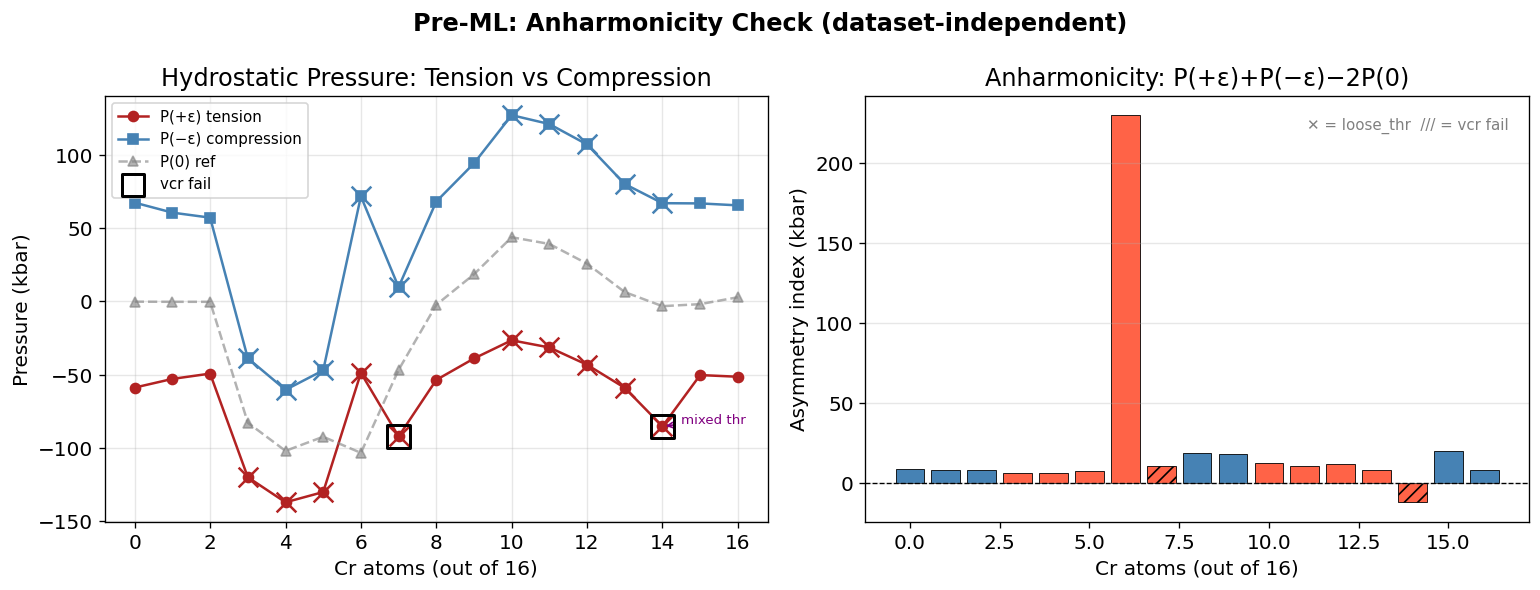

Saved: tension_compression_asymmetry.png
Bars near zero → linear elastic assumption is valid.
Note: fe02cr14 uses mixed FM/AFM hydro.dat — asymmetry value indicative only.


In [4]:
if len(asym_df) > 0:
    mixed_tag = 'fe02cr14'  # mixed FM/AFM hydro.dat — treat as indicative only

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: P(+ε) and P(−ε) vs composition ────────────────────────────────
    ax = axes[0]
    ax.plot(asym_df['n_cr'], asym_df['P_plus'],  'o-', color='firebrick', label='P(+ε) tension')
    ax.plot(asym_df['n_cr'], asym_df['P_minus'], 's-', color='steelblue', label='P(−ε) compression')
    if asym_df['P_zero'].notna().any():
        ax.plot(asym_df['n_cr'], asym_df['P_zero'], '^--', color='gray',
                alpha=0.6, label='P(0) ref')

    # loose_thr points — ✕ marker
    fl = asym_df[asym_df['loose_thr']]
    ax.scatter(fl['n_cr'], fl['P_plus'],  marker='x', s=140, color='firebrick', zorder=5)
    ax.scatter(fl['n_cr'], fl['P_minus'], marker='x', s=140, color='steelblue', zorder=5)

    # vcr geometry failure — open square outline
    vf = asym_df[asym_df['vcr_geometry_flag']]
    if len(vf) > 0:
        ax.scatter(vf['n_cr'], vf['P_plus'],  marker='s', s=180,
                   facecolors='none', edgecolors='black', linewidths=1.8,
                   zorder=5, label='vcr fail')

    # Annotate fe02cr14 mixed-threshold caveat
    if mixed_tag in asym_df['tag'].values:
        row = asym_df[asym_df['tag'] == mixed_tag].iloc[0]
        ax.annotate('mixed thr', xy=(row['n_cr'], row['P_plus']),
                    xytext=(row['n_cr'] + 0.5, row['P_plus'] + 2),
                    fontsize=8, color='purple',
                    arrowprops=dict(arrowstyle='->', color='purple', lw=1))

    ax.set_xlabel('Cr atoms (out of 16)')
    ax.set_ylabel('Pressure (kbar)')
    ax.set_title('Hydrostatic Pressure: Tension vs Compression')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ── Right: asymmetry index bar chart ─────────────────────────────────────
    ax2 = axes[1]
    cols    = ['tomato' if f else 'steelblue' for f in asym_df['loose_thr']]
    hatches = ['///' if f else '' for f in asym_df['vcr_geometry_flag']]
    for x, h, c, hatch in zip(asym_df['n_cr'], asym_df['asymmetry_kbar'], cols, hatches):
        ax2.bar(x, h, color=c, edgecolor='k', lw=0.5, hatch=hatch, width=0.8)
    ax2.axhline(0, color='k', lw=0.8, ls='--')
    ax2.set_xlabel('Cr atoms (out of 16)')
    ax2.set_ylabel('Asymmetry index (kbar)')
    ax2.set_title('Anharmonicity: P(+ε)+P(−ε)−2P(0)')
    ax2.text(0.97, 0.95, '✕ = loose_thr  /// = vcr fail',
             transform=ax2.transAxes, ha='right', va='top',
             color='gray', fontsize=9)
    ax2.grid(alpha=0.3, axis='y')

    plt.suptitle('Pre-ML: Anharmonicity Check (dataset-independent)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../analysis/tension_compression_asymmetry.png', bbox_inches='tight')
    plt.show()
    print('Saved: tension_compression_asymmetry.png')
    print('Bars near zero → linear elastic assumption is valid.')
    if mixed_tag in asym_df['tag'].values:
        print(f'Note: {mixed_tag} uses mixed FM/AFM hydro.dat — asymmetry value indicative only.')

---
## Cell 4 — GP Implementation from Scratch

### The mathematics — step by step

A Gaussian Process defines a **prior distribution over functions**.
We specify it with a mean function (zero here) and a **kernel** k(x, x')
that encodes how similar two inputs x and x' are.

#### Kernel functions
Given inputs x, x' (here: Cr fractions), the kernel returns a scalar
measuring their 'similarity'. Two kernels are implemented:

**RBF (Radial Basis Function / squared exponential):**
```
k(x,x') = σ² · exp( −||x−x'||² / (2·ℓ²) )
```
σ² = signal variance (amplitude), ℓ = length-scale (how fast similarity decays).
Implies infinitely smooth functions. Good for smooth Cij trends.

**Matérn-5/2:**
```
k(x,x') = σ² · (1 + √5·r/ℓ + 5r²/(3ℓ²)) · exp(−√5·r/ℓ)
where r = |x−x'|
```
Implies twice-differentiable (but not infinitely smooth) functions.
More realistic for physical alloy systems with composition-dependent anomalies.

#### Training: maximise the log marginal likelihood
Given training data (X, y) and noise variances σ²_i per point:
```
K_noisy = K(X,X) + diag(σ²_noise)     # covariance matrix + noise
log p(y|X,θ) = −½ yᵀ K_noisy⁻¹ y − ½ log|K_noisy| − n/2 log(2π)
```
We optimise θ = (σ², ℓ) to maximise this. This is the **only** use of
scipy.optimize — everything else is pure numpy.

#### Prediction
For a new point x*:
```
μ(x*) = k(x*,X) · K_noisy⁻¹ · y              # posterior mean
σ²(x*) = k(x*,x*) − k(x*,X) · K_noisy⁻¹ · k(X,x*)  # posterior variance
```
σ(x*) is the **standard deviation** — the uncertainty band in the plots.
It is large where training data is sparse, zero at training points (noise-free limit).

In [5]:
# GaussianProcessScratch is defined in gp_scratch.py and imported in Cell 1.
print(f'GP class : {GaussianProcessScratch.__name__}')
print(f'Kernels  : {list(KERNELS.keys())}')
#import inspect
#print(inspect.getsource(GaussianProcessScratch))

GP class : GaussianProcessScratch
Kernels  : ['rbf', 'matern52']


In [ ]:
# # ── Smoke test: verify fix_sigma2 works on synthetic data ────────────────────
# # Synthetic data generated here — NOT your DFT data.
# # Purpose: confirm gp_scratch.py is correctly imported and fix_sigma2 behaves.

# rng_test = np.random.default_rng(0)
# X_test   = np.linspace(0, 1, 17).reshape(-1, 1)
# y_test   = 200 - 50*X_test.flatten() + rng_test.normal(0, 5, 17)
# nv_test  = np.ones(17)

# print(f'Synthetic y: mean={y_test.mean():.2f}  std={y_test.std():.2f}  '
#       f'var={np.var(y_test):.2f} GPa²')
# print(f'(This is NOT DFT data — generated for import/API verification only)\n')

# for kname in KERNELS:
#     gp_test = GaussianProcessScratch(kernel=kname, n_restarts=5, seed=42)
#     gp_test.fit(X_test, y_test, nv_test, fix_sigma2=np.var(y_test))
#     mu_test, s_test = gp_test.predict(X_test)
#     print(f'  {kname:12s}  sigma2={gp_test.sigma2:.2f} (fixed=np.var(y))  '
#           f'ell={gp_test.ell:.4f}  logML={gp_test.log_ml:.2f}')

# print('\nSmoke test passed — fix_sigma2 API confirmed.')
# print('Real training uses np.var(y) from your DFT targets per constant.')

Synthetic y: mean=173.59  std=17.89  var=320.10 GPa²
(This is NOT DFT data — generated for import/API verification only)

  rbf           sigma2=320.10 (fixed=np.var(y))  ell=0.8866  logML=-201.80
  matern52      sigma2=320.10 (fixed=np.var(y))  ell=1.2980  logML=-189.74

Smoke test passed — fix_sigma2 API confirmed.
Real training uses np.var(y) from your DFT targets per constant.


In [ ]:
# # ── Scale diagnostic for fix_sigma2 — C11 corrected only ─────────────────────
# # Determines best sigma2 scale factor before full training.
# # Run once, note best scale, then proceed to Cell 5.

# r     = results['corrected']
# tname = 'C11'
# y_diag = r['targets'][tname]
# nv_diag = r['alpha'][tname]

# print(f'C11 corrected — np.var(y) = {np.var(y_diag):.2f} GPa²')
# print(f'{"scale":>6} {"sigma2":>10} {"ell":>8} {"MAE (GPa)":>10} {"R²":>8}')
# print('-' * 48)

# for scale in [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
#     gp_diag = GaussianProcessScratch(kernel='matern52', n_restarts=10, seed=42)
#     gp_diag.fit(r['X'], y_diag, noise_var=nv_diag,
#                 fix_sigma2=scale * np.var(y_diag))
#     loo_diag = loo_cv_gp(gp_diag, r['X'], y_diag, nv_diag)
#     print(f'{scale:>6.1f} {gp_diag.sigma2:>10.2f} {gp_diag.ell:>8.4f} '
#           f'{loo_diag["mae"]:>10.2f} {loo_diag["r2"]:>8.4f}')

# print()
# print('Pick scale with highest R² — use in Cell 5 as fix_sigma2=scale*np.var(y)')

C11 corrected — np.var(y) = 7329.51 GPa²
 scale     sigma2      ell  MAE (GPa)       R²
------------------------------------------------
   0.1     732.95   0.1572      33.17   0.7621
   0.2    1465.90   0.1555      32.85   0.7588
   0.3    2198.85   0.1565      32.54   0.7602
   0.5    3664.75   0.1599      32.13   0.7648
   0.7    5130.65   0.1638      31.78   0.7696
   1.0    7329.51   0.1696      31.35   0.7760

Pick scale with highest R² — use in Cell 5 as fix_sigma2=scale*np.var(y)


---
## Cell 5 — Train GPs + LOO-CV

Both kernels trained per target. Best selected by LOO-CV R².

**LOO-CV:** At each fold, one point is held out, the GP is re-fitted
on the remaining 16 points using the **same optimised hyperparameters**
from the full fit, then we predict the held-out point.
This avoids re-running the expensive optimisation 17 times per kernel per target.

In [19]:
def loo_cv_gp(gp_full, X, y, noise_var):
    """
    LOO-CV with hyperparameters fixed from the full fit.
    Rebuilds Cholesky per fold — no re-optimisation.
    """
    loo = LeaveOneOut()
    loo_preds, loo_true = [], []
    for tr, te in loo.split(X):
        n_tr = len(tr)
        K    = gp_full.kernel_fn(X[tr], X[tr], gp_full.sigma2, gp_full.ell)
        K_n  = K + np.diag(noise_var[tr]) + 1e-8 * np.eye(n_tr)
        L    = np.linalg.cholesky(K_n)
        v    = np.linalg.solve(L, y[tr])
        av   = np.linalg.solve(L.T, v)
        K_s  = gp_full.kernel_fn(X[te], X[tr], gp_full.sigma2, gp_full.ell)
        loo_preds.append(float(K_s @ av))
        loo_true.append(float(y[te[0]]))
    loo_preds = np.array(loo_preds)
    loo_true  = np.array(loo_true)
    return dict(loo_preds=loo_preds, loo_true=loo_true,
                residuals=loo_true - loo_preds,
                mae=mean_absolute_error(loo_true, loo_preds),
                r2=r2_score(loo_true, loo_preds))


for mode in DATA_PATHS:
    r = results[mode]
    print(f'\n{"═"*55}')
    print(f'  Dataset: {mode.upper()}')
    print(f'{"═"*55}')
    for tname in TARGETS:
        y         = r['targets'][tname]
        noise_var = r['alpha'][tname]
        print(f'\n  ── {tname} ──────────────────────────')
        best_r2 = -np.inf
        for kname in KERNELS:
            gp  = GaussianProcessScratch(kernel=kname, n_restarts=20, seed=42)
            gp.fit(r['X'], y, noise_var=noise_var, fix_sigma2=np.var(y))
            loo = loo_cv_gp(gp, r['X'], y, noise_var)
            print(f'    {kname:12s}  σ²={gp.sigma2:.2f}  ℓ={gp.ell:.4f}  '
                  f'logML={gp.log_ml:.2f}  MAE={loo["mae"]:.2f} GPa  R²={loo["r2"]:.4f}')
            r['gp_store'][tname][kname] = {'gp': gp, 'loo': loo}
            if loo['r2'] > best_r2:
                best_r2 = loo['r2']
                r['best_gps'][tname] = gp
                best_kname = kname
        print(f'    → Best: {best_kname} (R²={best_r2:.4f})')


═══════════════════════════════════════════════════════
  Dataset: RAW
═══════════════════════════════════════════════════════

  ── C11 ──────────────────────────
    rbf           σ²=7329.51  ℓ=0.0693  logML=-144.14  MAE=74.00 GPa  R²=-0.0326
    matern52      σ²=7329.51  ℓ=0.1299  logML=-123.67  MAE=45.87 GPa  R²=0.5874
    → Best: matern52 (R²=0.5874)

  ── C12 ──────────────────────────
    rbf           σ²=1340.71  ℓ=0.0607  logML=-139.91  MAE=42.89 GPa  R²=-0.6819
    matern52      σ²=1340.71  ℓ=0.0960  logML=-123.36  MAE=32.69 GPa  R²=0.0434
    → Best: matern52 (R²=0.0434)

  ── C44 ──────────────────────────
    rbf           σ²=65.69  ℓ=0.2764  logML=-363.92  MAE=3.46 GPa  R²=0.6472
    matern52      σ²=65.69  ℓ=0.4421  logML=-307.08  MAE=3.54 GPa  R²=0.6521
    → Best: matern52 (R²=0.6521)

═══════════════════════════════════════════════════════
  Dataset: CORRECTED
═══════════════════════════════════════════════════════

  ── C11 ──────────────────────────
    rbf        

---
## Cell 6 — Prediction Plots with Uncertainty Bands

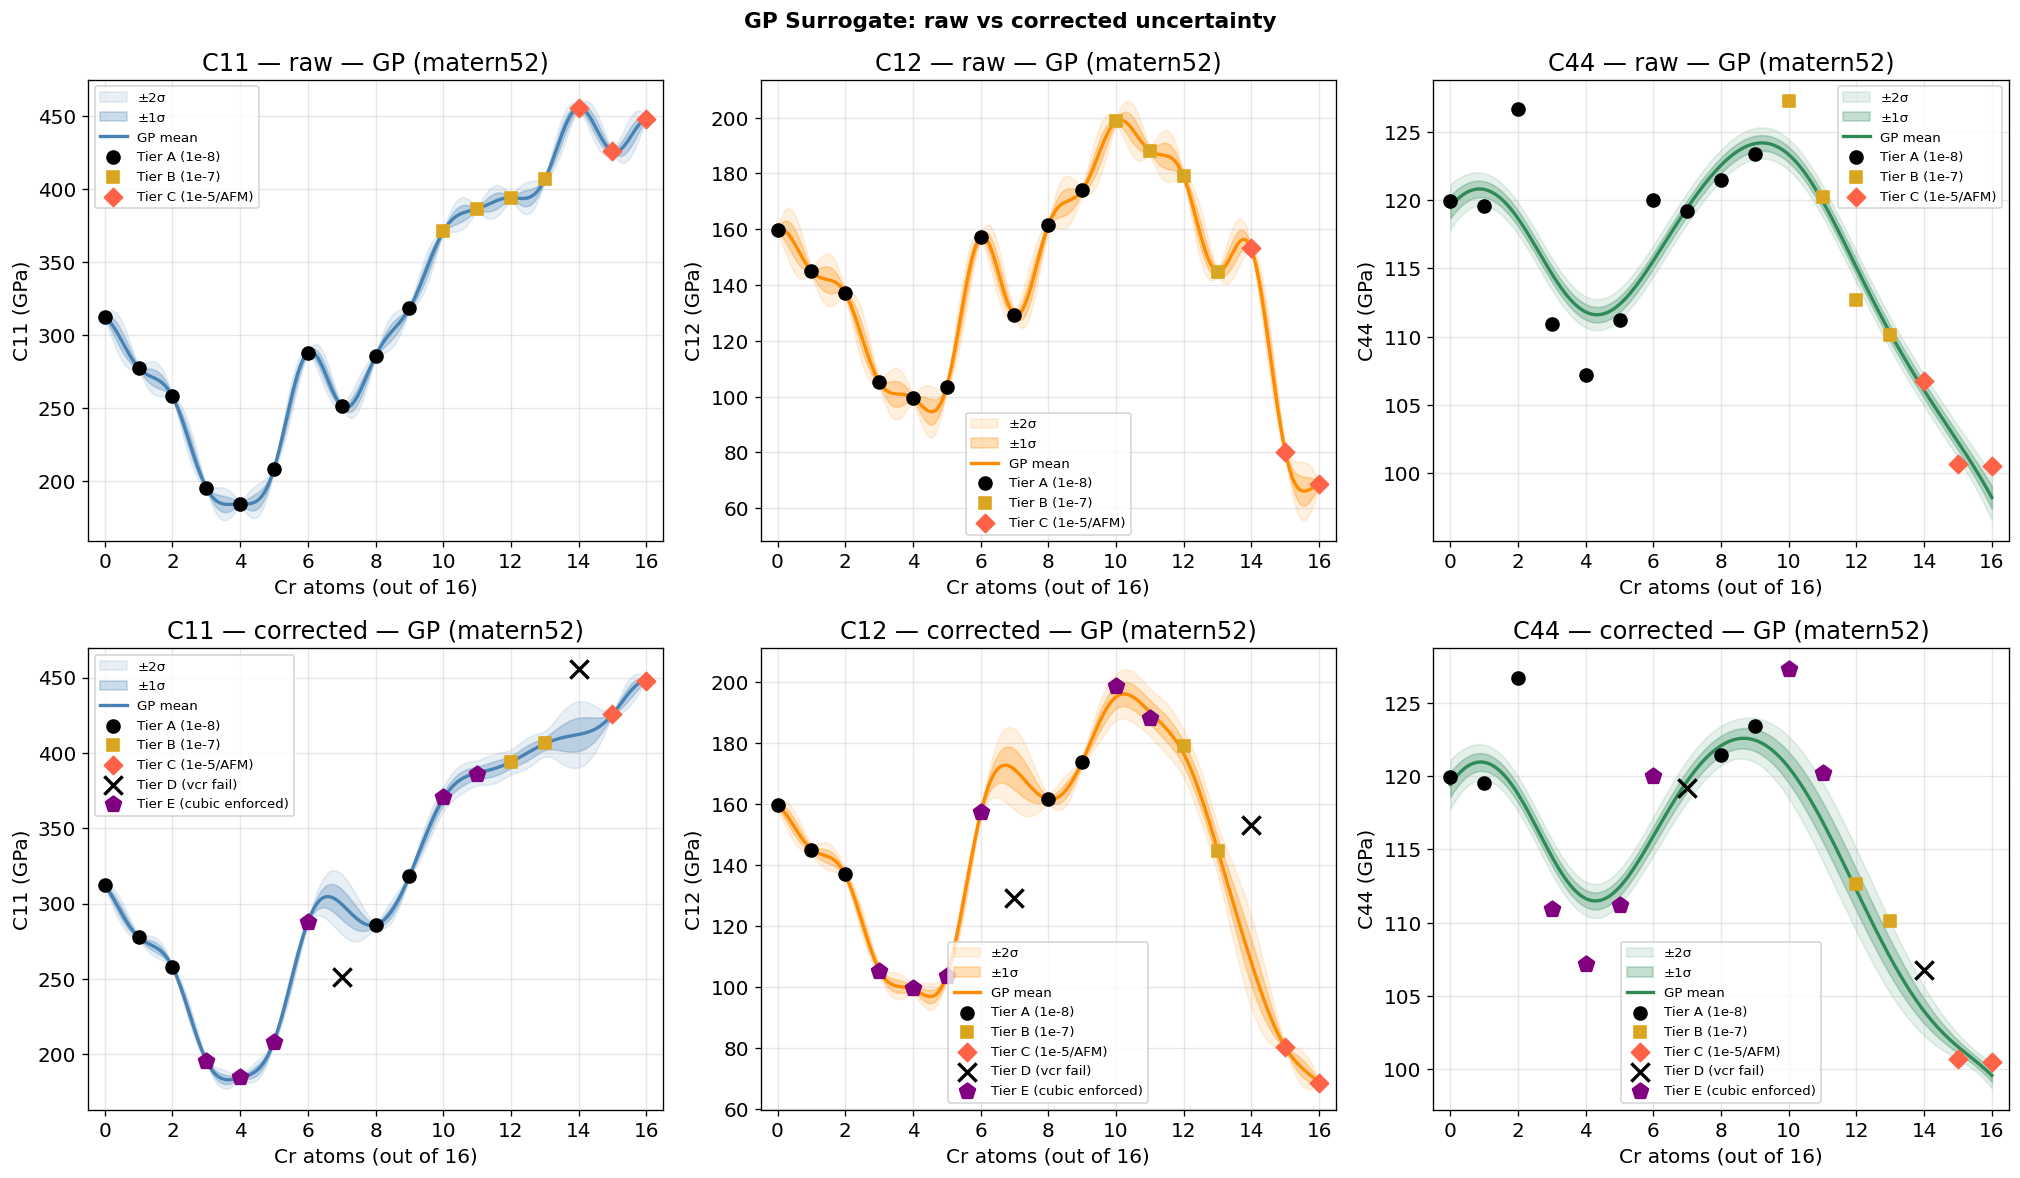

Saved: gp_predictions_comparison.png


In [20]:
tier_specs = [
    ('A', 'black',     'o', 'Tier A (1e-8)'),
    ('B', 'goldenrod', 's', 'Tier B (1e-7)'),
    ('C', 'tomato',    'D', 'Tier C (1e-5/AFM)'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for row_idx, mode in enumerate(DATA_PATHS):
    r = results[mode]
    for col_idx, tname in enumerate(TARGETS):
        ax  = axes[row_idx, col_idx]
        gp  = r['best_gps'][tname]
        mu, sig = gp.predict(r['X_pred'], return_std=True)
        col = PALETTE[tname]
        ax.fill_between(r['x_pred_atoms'], mu-2*sig, mu+2*sig,
                        alpha=0.12, color=col, label='±2σ')
        ax.fill_between(r['x_pred_atoms'], mu-sig,   mu+sig,
                        alpha=0.28, color=col, label='±1σ')
        ax.plot(r['x_pred_atoms'], mu, '-', color=col, lw=2, label='GP mean')

        # Tier A/B/C — exclude D and E from standard markers
        for t_lbl, col_s, mk, lbl in tier_specs:
            m = (r['tier'] == t_lbl) & ~r['vcr_geometry'] & ~r['cubic_enforced']
            if m.any():
                ax.scatter(r['df']['n_cr'][m], r['targets'][tname][m],
                           color=col_s, s=60, marker=mk, zorder=5, label=lbl)

        # Tier D — vcr geometry failure (post-BFGS SCF non-convergence)
        if r['vcr_geometry'].any():
            ax.scatter(r['df']['n_cr'][r['vcr_geometry']],
                       r['targets'][tname][r['vcr_geometry']],
                       color='black', s=120, marker='x', linewidths=2,
                       zorder=6, label='Tier D (vcr fail)')

        # Tier E — cubic enforcement residual (b/c != a after vc-relax)
        # fe09cr07 is both D and E — show as D only (more severe)
        cub = r['cubic_enforced'] & ~r['vcr_geometry']
        if cub.any():
            ax.scatter(r['df']['n_cr'][cub], r['targets'][tname][cub],
                       color='purple', s=90, marker='p', linewidths=1.5,
                       zorder=5, label='Tier E (cubic enforced)')

        ax.set_xlabel('Cr atoms (out of 16)')
        ax.set_ylabel(f'{tname} (GPa)')
        ax.set_title(f'{tname} — {mode} — GP ({gp.kernel_name})')
        ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(-0.5, 16.5)

plt.suptitle('GP Surrogate: raw vs corrected uncertainty', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../analysis/gp_predictions_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: gp_predictions_comparison.png')

---
## Cell 7 — LOO-CV Residuals

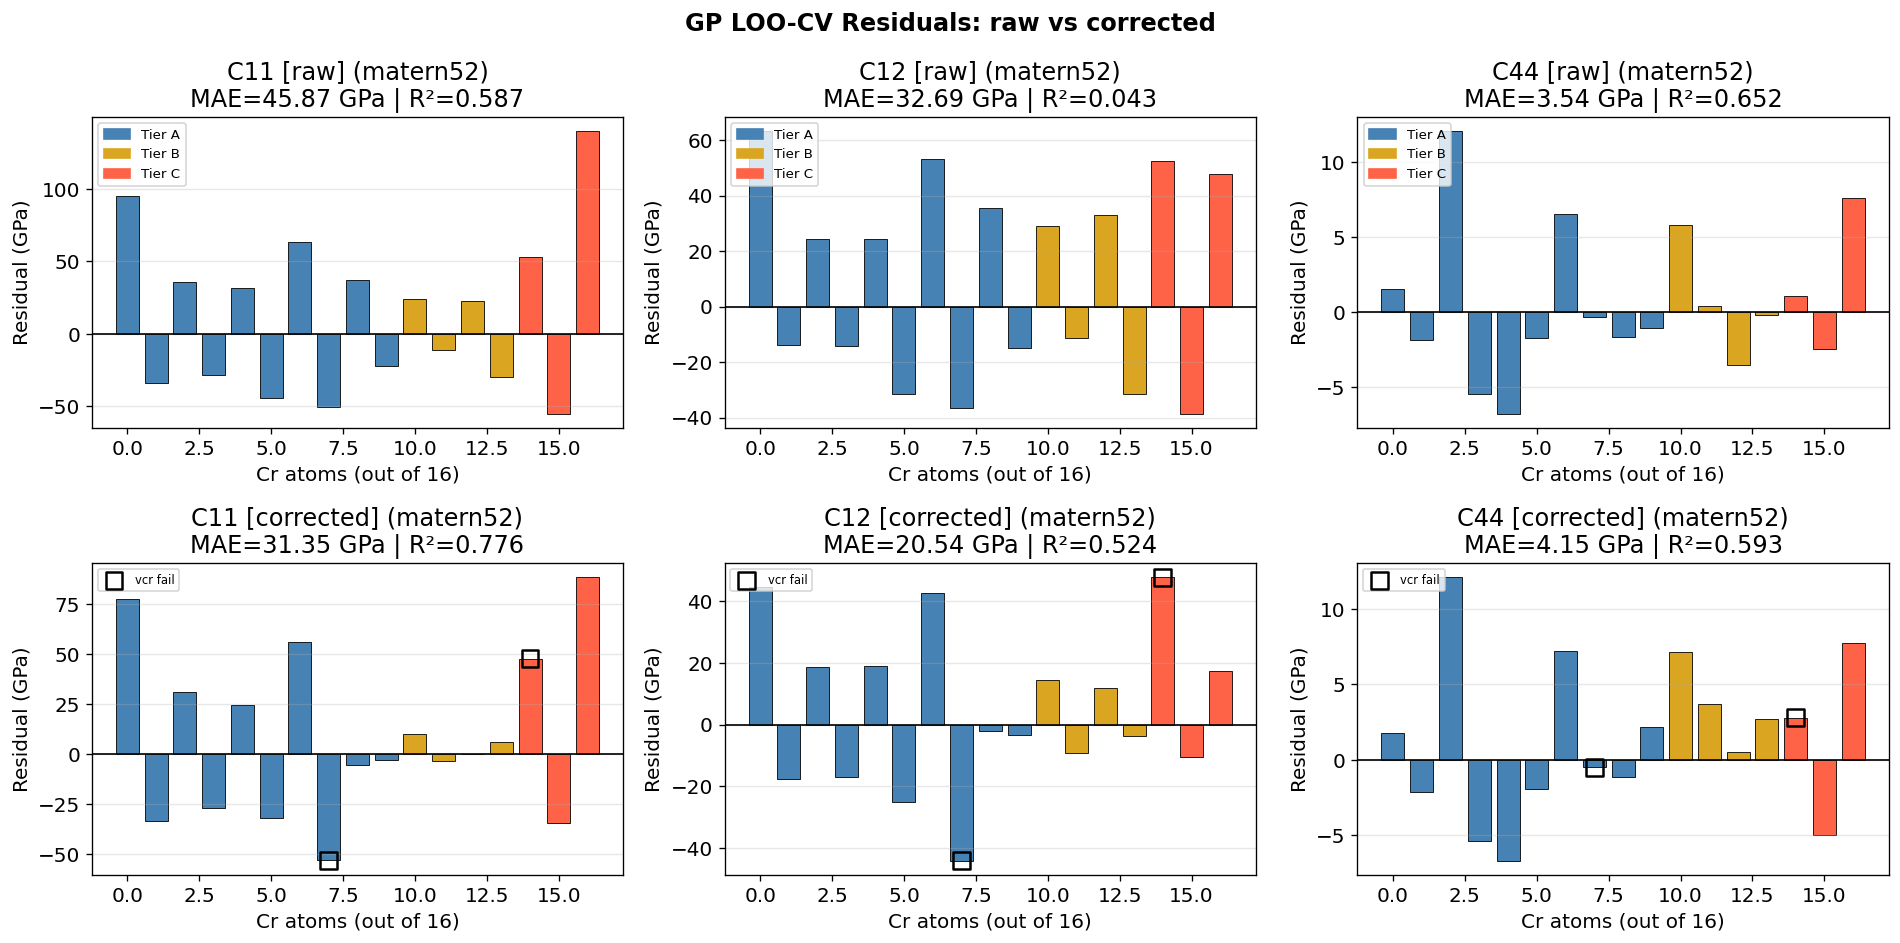

Saved: gp_loo_residuals_comparison.png


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row_idx, mode in enumerate(DATA_PATHS):
    r = results[mode]
    for col_idx, tname in enumerate(TARGETS):
        ax  = axes[row_idx, col_idx]
        gp  = r['best_gps'][tname]
        loo = r['gp_store'][tname][gp.kernel_name]['loo']
        plot_loo_residuals(
            ax,
            loo['residuals'],
            r['df']['n_cr'].values,
            r['tier'],
            f"{tname} [{mode}] ({gp.kernel_name})\n"
            f"MAE={loo['mae']:.2f} GPa | R²={loo['r2']:.3f}"
        )
        # Overlay vcr_geometry points with open circle
        vf = r['vcr_geometry']
        if vf.any():
            ax.scatter(r['df']['n_cr'][vf],
                       loo['residuals'][vf],
                       marker='s', s=100, facecolors='none',
                       edgecolors='black', linewidths=1.5,
                       zorder=5, label='vcr fail')
            ax.legend(fontsize=7, loc='upper left')

plt.suptitle('GP LOO-CV Residuals: raw vs corrected', fontweight='bold')
plt.tight_layout()
plt.savefig('../analysis/gp_loo_residuals_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: gp_loo_residuals_comparison.png')

---
## Cell 8 — Derived Quantities: B, Zener A, E[100], E[111]

| Quantity | Formula |
|---|---|
| Bulk modulus B | (C11+2·C12)/3 |
| Zener anisotropy A | 2·C44/(C11−C12) |
| Young's E[100] | (C11−C12)·(C11+2·C12)/(C11+C12) |
| Young's E[111] | 3·C44·(C11+2·C12)/(C11+2·C12+C44) |

Uncertainty propagated analytically (first-order) for B and Zener A.

⚠ E[111] formula: verify against Nye *Physical Properties of Crystals* before citing.


[raw]
  B      : 125.3 – 258.8 GPa
  ZenerA : 0.518 – 2.702
  E[100] : 112.8 – 429.6 GPa
  E[111] : 252.3 – 318.9 GPa

[corrected]
  B      : 127.2 – 257.5 GPa
  ZenerA : 0.525 – 2.709
  E[100] : 112.4 – 429.6 GPa
  E[111] : 255.3 – 312.7 GPa


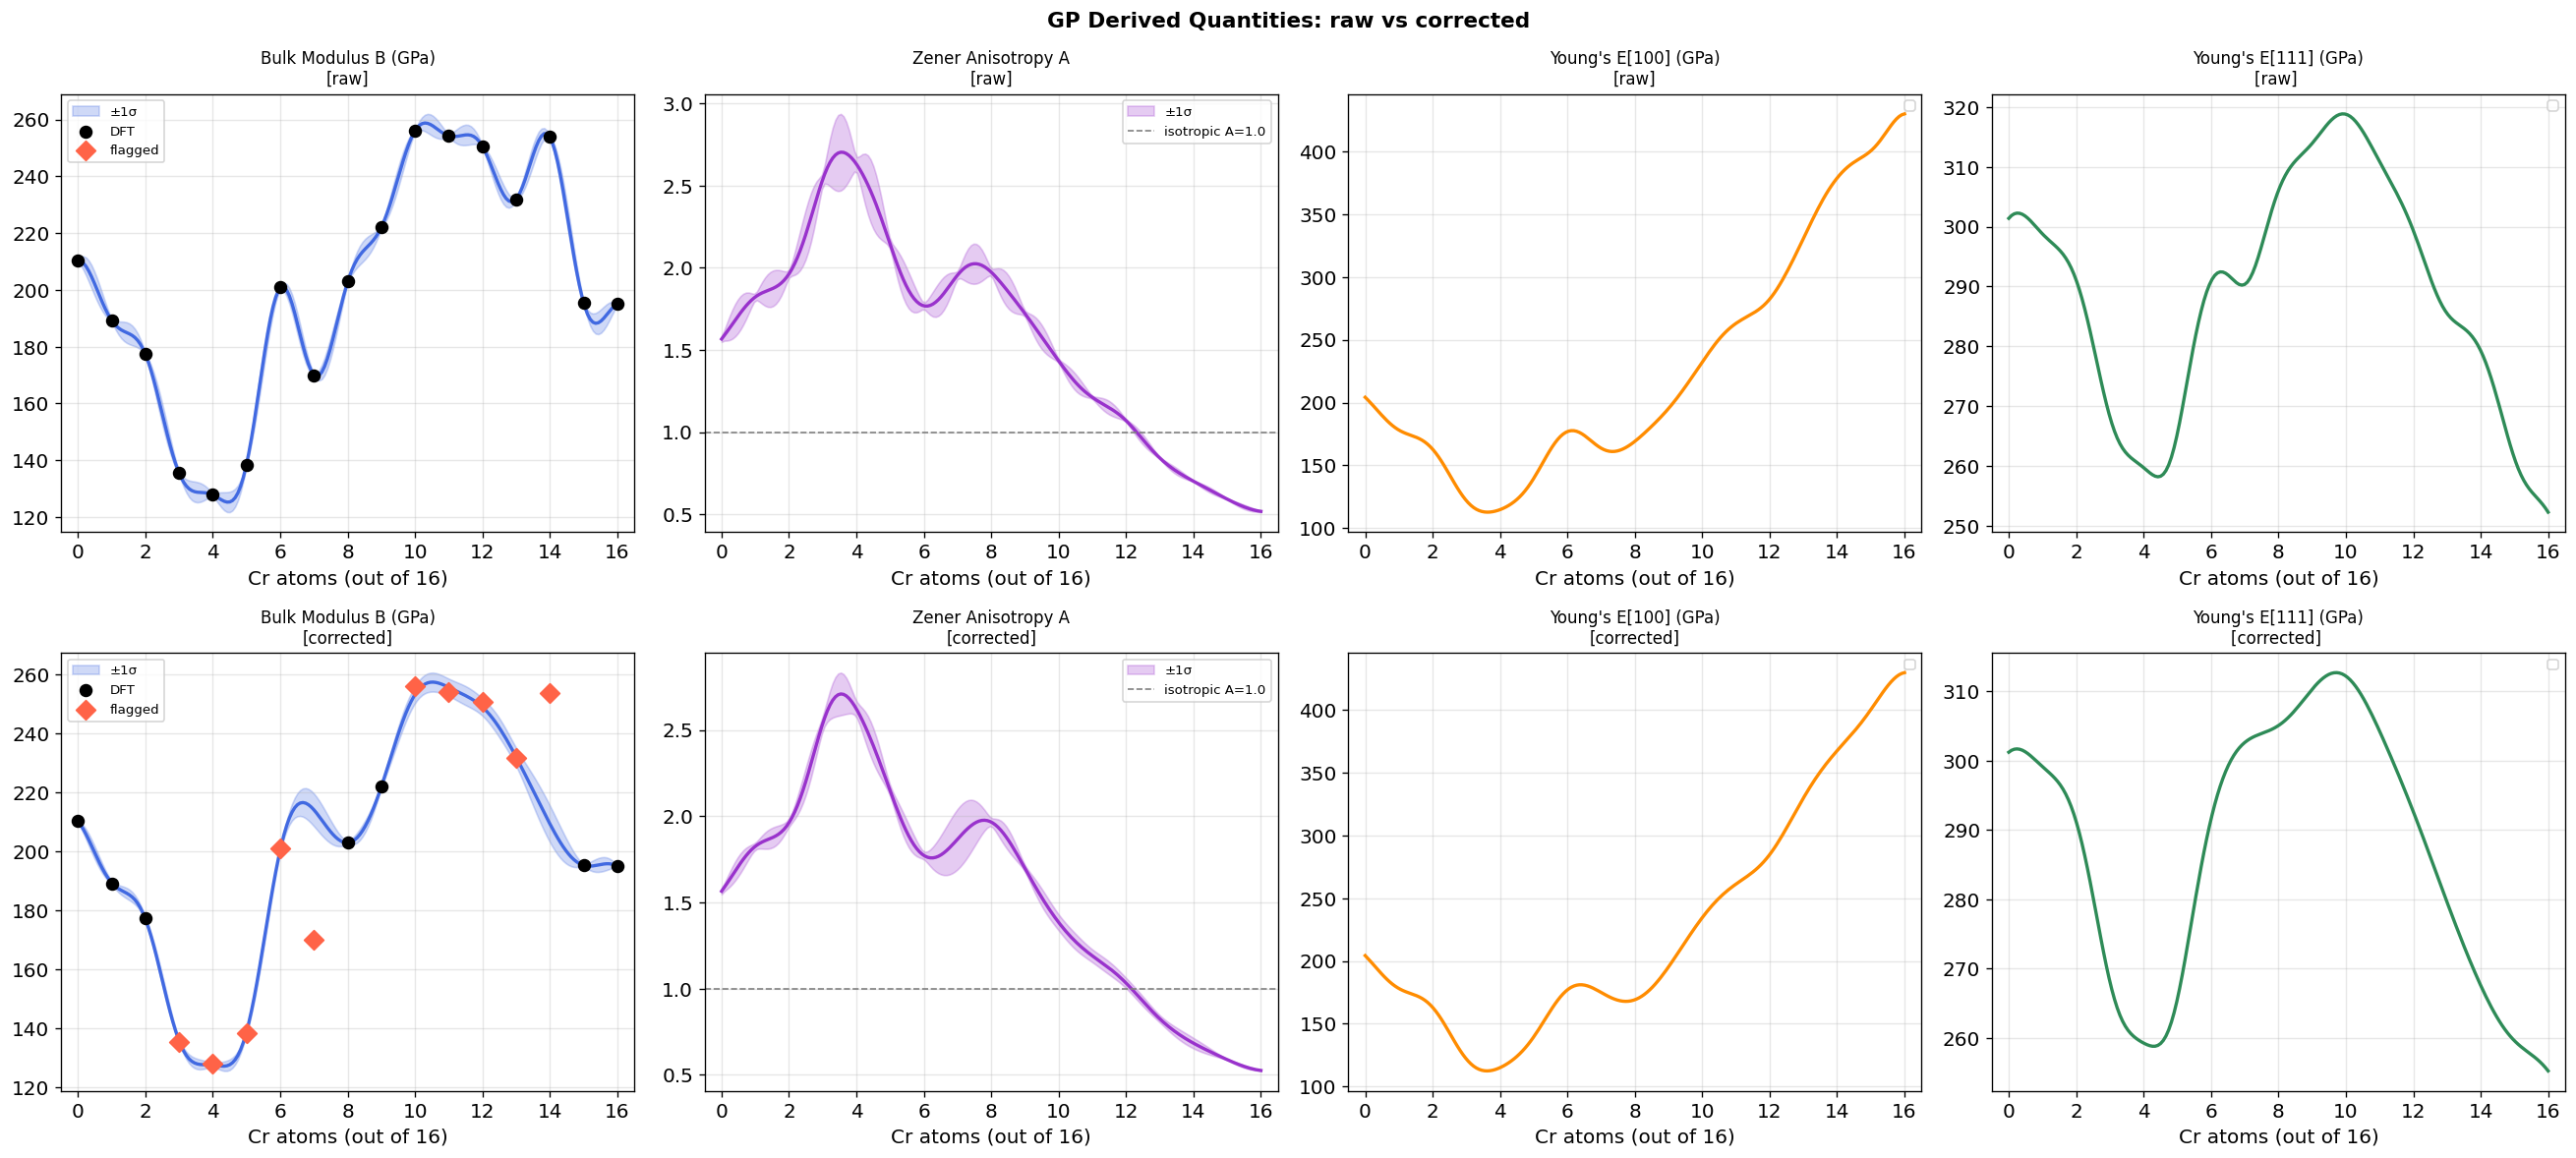

Saved: gp_derived_quantities_comparison.png


In [22]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for row_idx, mode in enumerate(DATA_PATHS):
    r            = results[mode]
    X_pred       = r['X_pred']
    x_pred_atoms = r['x_pred_atoms']
    df_m         = r['df']
    flagged_m    = r['flagged']

    c11, s11 = r['best_gps']['C11'].predict(X_pred, return_std=True)
    c12, s12 = r['best_gps']['C12'].predict(X_pred, return_std=True)
    c44, s44 = r['best_gps']['C44'].predict(X_pred, return_std=True)

    B      = (c11 + 2*c12) / 3.0
    B_std  = np.sqrt(s11**2 + 4*s12**2) / 3.0
    denom  = c11 - c12
    ZA     = 2*c44 / denom
    ZA_std = np.sqrt((2/denom * s44)**2 +
                     (2*c44/denom**2 * s11)**2 +
                     (2*c44/denom**2 * s12)**2)
    E100   = denom * (c11 + 2*c12) / (c11 + c12)
    E111   = 3*c44*(c11 + 2*c12) / (c11 + 2*c12 + c44)

    print(f'\n[{mode}]')
    print(f'  B      : {B.min():.1f} – {B.max():.1f} GPa')
    print(f'  ZenerA : {ZA.min():.3f} – {ZA.max():.3f}')
    print(f'  E[100] : {E100.min():.1f} – {E100.max():.1f} GPa')
    print(f'  E[111] : {E111.min():.1f} – {E111.max():.1f} GPa')

    pdata = [
        (axes[row_idx, 0], B,    B_std,  f'Bulk Modulus B (GPa)\n[{mode}]',        'royalblue',  None),
        (axes[row_idx, 1], ZA,   ZA_std, f'Zener Anisotropy A\n[{mode}]',          'darkorchid', 1.0),
        (axes[row_idx, 2], E100, None,   f"Young's E[100] (GPa)\n[{mode}]",        'darkorange', None),
        (axes[row_idx, 3], E111, None,   f"Young's E[111] (GPa)\n[{mode}] ",     'seagreen',   None),
    ]
    for ax, ym, ys, title, col, hl in pdata:
        ax.plot(x_pred_atoms, ym, '-', color=col, lw=2)
        if ys is not None:
            ax.fill_between(x_pred_atoms, ym-ys, ym+ys,
                            alpha=0.25, color=col, label='±1σ')
        if hl:
            ax.axhline(hl, color='gray', ls='--', lw=1,
                       label=f'isotropic A={hl}')
        if 'Bulk' in title and 'B' in df_m.columns:
            ax.scatter(df_m['n_cr'], df_m['B'],
                       color='black', s=50, zorder=5, label='DFT')
            ax.scatter(df_m.loc[flagged_m, 'n_cr'],
                       df_m.loc[flagged_m, 'B'],
                       color='tomato', s=70, marker='D', zorder=6, label='flagged')
        ax.set_xlabel('Cr atoms (out of 16)')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(-0.5, 16.5)

plt.suptitle('GP Derived Quantities: raw vs corrected', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../analysis/gp_derived_quantities_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: gp_derived_quantities_comparison.png')


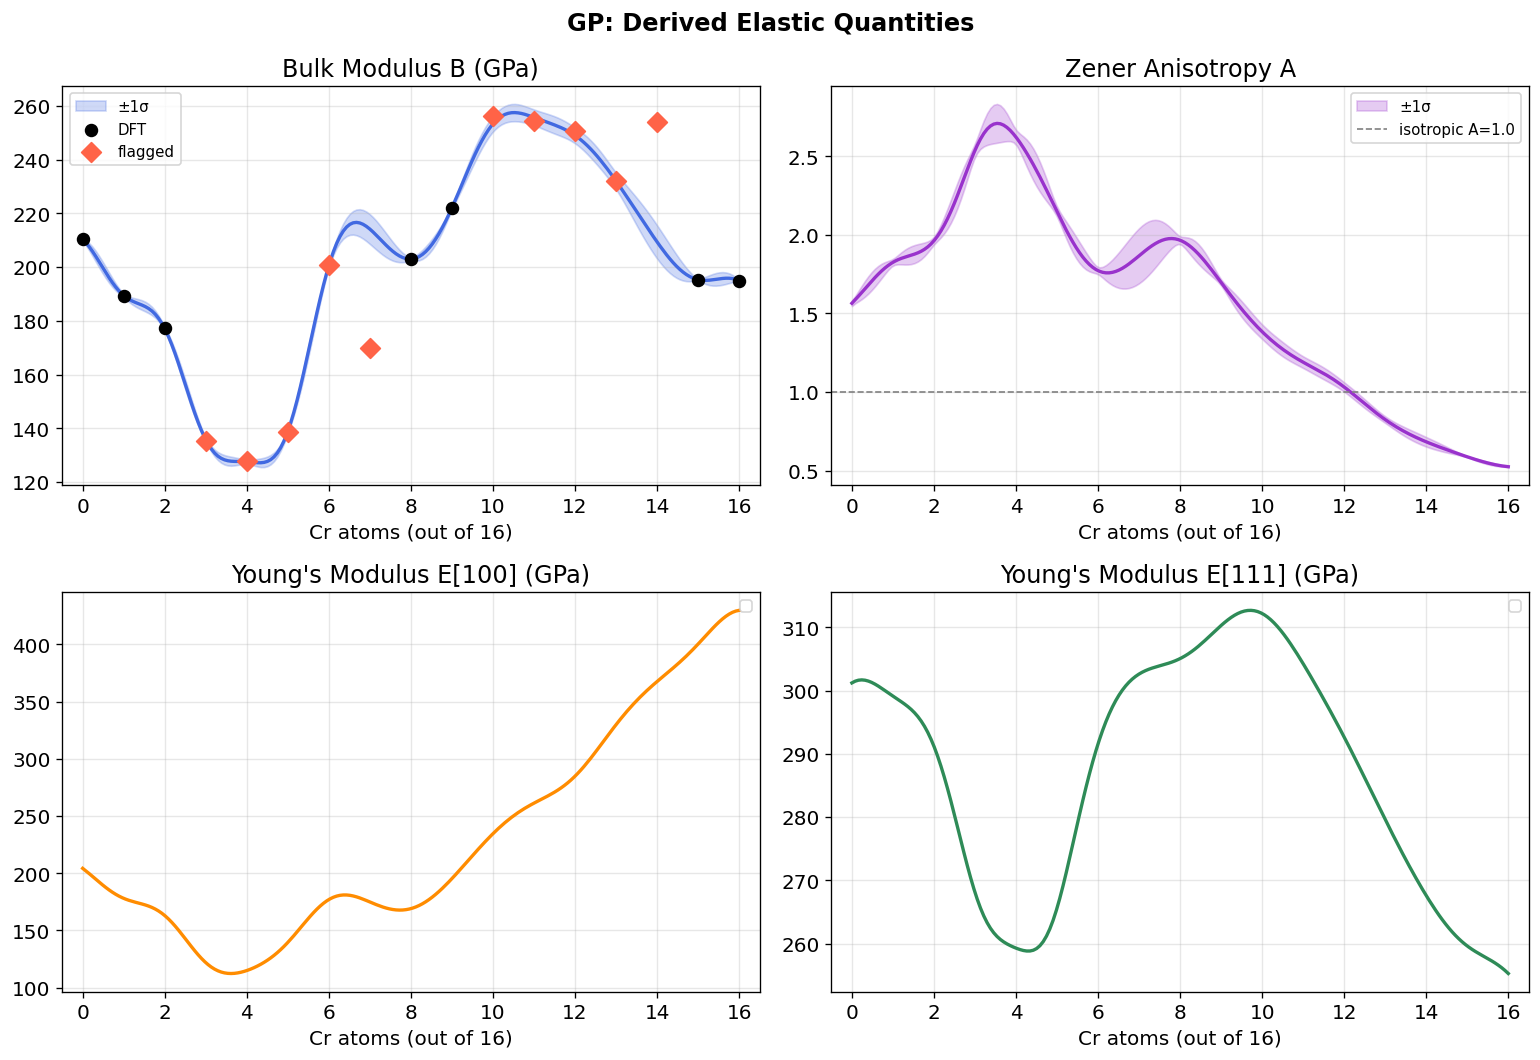

Saved: gp_derived_quantities.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
pdata = [
    (axes[0,0], B,    B_std,  'Bulk Modulus B (GPa)',       'royalblue',  None),
    (axes[0,1], ZA,   ZA_std, 'Zener Anisotropy A',         'darkorchid', 1.0),
    (axes[1,0], E100, None,   "Young's Modulus E[100] (GPa)",'darkorange', None),
    (axes[1,1], E111, None,   "Young's Modulus E[111] (GPa)",'seagreen',   None),
]
for ax, ym, ys, title, col, hl in pdata:
    ax.plot(x_pred_atoms, ym, '-', color=col, lw=2)
    if ys is not None:
        ax.fill_between(x_pred_atoms, ym-ys, ym+ys, alpha=0.25, color=col, label='±1σ')
    if hl:
        ax.axhline(hl, color='gray', ls='--', lw=1, label=f'isotropic A={hl}')
    if 'Bulk' in title and 'B' in df_m.columns:
        ax.scatter(df_m['n_cr'], df_m['B'],
               color='black', s=50, zorder=5, label='DFT')
        if flagged_m.any():
            ax.scatter(df_m['n_cr'].values[flagged_m],
                   df_m['B'].values[flagged_m],
                   color='tomato', s=70, marker='D', zorder=6, label='flagged')
    ax.set_xlabel('Cr atoms (out of 16)'); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(-0.5, 16.5)
plt.suptitle('GP: Derived Elastic Quantities', fontweight='bold')
plt.tight_layout()
plt.savefig('../analysis/gp_derived_quantities.png', bbox_inches='tight')
plt.show(); print('Saved: gp_derived_quantities.png')

---
## Cell 9 — Export Results for Model Comparison

In [24]:
for mode in DATA_PATHS:
    r = results[mode]
    exp = {}
    for tname in TARGETS:
        gp  = r['best_gps'][tname]
        loo = r['gp_store'][tname][gp.kernel_name]['loo']
        mu, sig = gp.predict(r['X_pred'], return_std=True)
        exp[tname] = dict(
            mu=mu, std=sig,
            mae=loo['mae'], r2=loo['r2'],
            loo_true=loo['loo_true'], loo_preds=loo['loo_preds'],
            residuals=loo['residuals'],
            best_kernel=gp.kernel_name,
            sigma2=gp.sigma2, ell=gp.ell, log_ml=gp.log_ml,
        )
    r['export'] = exp
    pkl_path = f'../analysis/gp_results_{mode}.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(exp, f)
    print(f'Saved: gp_results_{mode}.pkl')

print('\nGP Summary:')
for mode in DATA_PATHS:
    print(f'\n  {mode.upper()}')
    for t, v in results[mode]['export'].items():
        print(f'    {t}: {v["best_kernel"]:12s}  '
              f'σ²={v["sigma2"]:.2f}  ℓ={v["ell"]:.4f}  '
              f'MAE={v["mae"]:.2f} GPa  R²={v["r2"]:.4f}')

Saved: gp_results_raw.pkl
Saved: gp_results_corrected.pkl

GP Summary:

  RAW
    C11: matern52      σ²=7329.51  ℓ=0.1299  MAE=45.87 GPa  R²=0.5874
    C12: matern52      σ²=1340.71  ℓ=0.0960  MAE=32.69 GPa  R²=0.0434
    C44: matern52      σ²=65.69  ℓ=0.4421  MAE=3.54 GPa  R²=0.6521

  CORRECTED
    C11: matern52      σ²=7329.51  ℓ=0.1696  MAE=31.35 GPa  R²=0.7760
    C12: matern52      σ²=1340.71  ℓ=0.1411  MAE=20.54 GPa  R²=0.5239
    C44: matern52      σ²=65.69  ℓ=0.4268  MAE=4.15 GPa  R²=0.5934


---
## Cell 10 — ABAQUS Material Card Export

Queries GP at selected Cr compositions → writes `*Elastic, type=ANISOTROPIC` snippets.

**Units:** GPa here. ABAQUS typically expects MPa — multiply Cij × 1000.

**Cubic Voigt order:**
D1111, D1122, D2222, D1133, D2233, D3333, D1212, D1313 (line 1) + D2323 (line 2)
= C11, C12, C11, C12, C12, C11, C44, C44 (line 1) + C44 (line 2)

⚠ Verify `*Elastic ANISOTROPIC` keyword format against your ABAQUS version docs.

In [25]:
FEM_CR_ATOMS = [0, 4, 8, 12, 16]

for mode in DATA_PATHS:
    r   = results[mode]
    rows, abaqus_lines, ccx_lines = [], [], []

    header = [
        f'** Fe-Cr Material Cards — GP Surrogate [{mode}]',
        '** Units: GPa  (multiply by 1000 for MPa in ABAQUS/CalculiX)',
        '** ABAQUS:    *Elastic, type=ANISOTROPIC',
        '** CalculiX:  *ELASTIC, TYPE=ANISO  (same Voigt order)',
        '** Cubic Voigt order: C11 C12 C11 C12 C12 C11 C44 C44 / C44',
        '',
    ]
    abaqus_lines += header
    ccx_lines    += header

    for ncr in FEM_CR_ATOMS:
        xv   = np.array([[ncr / 16.0]])
        c11v, s11v = r['best_gps']['C11'].predict(xv)
        c12v, s12v = r['best_gps']['C12'].predict(xv)
        c44v, s44v = r['best_gps']['C44'].predict(xv)
        c11v, c12v, c44v = float(c11v), float(c12v), float(c44v)
        s11v, s12v, s44v = float(s11v), float(s12v), float(s44v)
        bv   = (c11v + 2*c12v) / 3
        zav  = 2*c44v / (c11v - c12v)
        label = f'Fe{16-ncr}Cr{ncr}'

        rows.append({'n_cr': ncr, 'x_cr': ncr/16, 'mode': mode,
                     'C11_GPa': round(c11v,2), 'C11_std': round(s11v,2),
                     'C12_GPa': round(c12v,2), 'C12_std': round(s12v,2),
                     'C44_GPa': round(c44v,2), 'C44_std': round(s44v,2),
                     'B_GPa':   round(bv,2),   'ZenerA':  round(zav,4)})

        comment = (f'** {label}  B={bv:.2f} GPa  ZenerA={zav:.4f}  '
                   f'C11±{s11v:.2f}  C12±{s12v:.2f}  C44±{s44v:.2f}')
        voigt_l1 = (f'{c11v:.3f}, {c12v:.3f}, {c11v:.3f}, {c12v:.3f}, '
                    f'{c12v:.3f}, {c11v:.3f}, {c44v:.3f}, {c44v:.3f},')
        voigt_l2 = f'{c44v:.3f}'

        abaqus_lines += [comment,
                         f'*Material, name={label}',
                         '*Elastic, type=ANISOTROPIC',
                         voigt_l1, voigt_l2, '']

        ccx_lines    += [comment,
                         f'*MATERIAL, NAME={label}',
                         '*ELASTIC, TYPE=ANISO',
                         voigt_l1, voigt_l2, '']

    # Save
    fem_df = pd.DataFrame(rows)
    fem_df.to_csv(f'../analysis/fem_material_inputs_gp_{mode}.csv', index=False)

    abaqus_txt = '\n'.join(abaqus_lines)
    with open(f'../analysis/abaqus_material_cards_{mode}.inp', 'w') as f:
        f.write(abaqus_txt)

    ccx_txt = '\n'.join(ccx_lines)
    with open(f'../analysis/calculix_material_cards_{mode}.inp', 'w') as f:
        f.write(ccx_txt)

    print(f'[{mode}] Saved: fem_material_inputs_gp_{mode}.csv')
    print(f'[{mode}]        abaqus_material_cards_{mode}.inp')
    print(f'[{mode}]        calculix_material_cards_{mode}.inp')

[raw] Saved: fem_material_inputs_gp_raw.csv
[raw]        abaqus_material_cards_raw.inp
[raw]        calculix_material_cards_raw.inp
[corrected] Saved: fem_material_inputs_gp_corrected.csv
[corrected]        abaqus_material_cards_corrected.inp
[corrected]        calculix_material_cards_corrected.inp


---
## Cell 11 — Summary

**Open caveats (always carry these forward):**
1. C11−C12 denominator `3ε` — taken as likely correct; verify vs primary reference before citing
2. E[111] formula — verify vs Nye *Physical Properties of Crystals*
3. fe02cr14/15/16 — mixed magnetic setup, down-weighted not removed
4. ABAQUS card format — verify `*Elastic ANISOTROPIC` for your version

In [26]:
print('=' * 60)
print('GP SURROGATE — SUMMARY')
print('=' * 60)

for mode in DATA_PATHS:
    r = results[mode]
    print(f'\n  [{mode.upper()}]')
    print(f'  Points : {len(r["df"])}  |  '
          f'Flagged (loose_thr): {r["flagged"].sum()}  |  '
          f'VCR fail: {r["vcr_geometry"].sum()}')
    print(f'  Kernels: {list(KERNELS.keys())}')
    print(f'  Restarts: {r["best_gps"]["C11"].n_restarts}')
    print()
    for t, v in r['export'].items():
        print(f'    {t}: {v["best_kernel"]:12s}  '
              f'σ²={v["sigma2"]:.2f}  ℓ={v["ell"]:.4f}  '
              f'MAE={v["mae"]:.2f} GPa  R²={v["r2"]:.4f}')

print()
print('Outputs saved to ../analysis/:')
for fn in [
    'tension_compression_asymmetry.png',
    'gp_predictions_comparison.png',
    'gp_loo_residuals_comparison.png',
    'gp_derived_quantities_comparison.png',
    'gp_results_raw.pkl',
    'gp_results_corrected.pkl',
    'fem_material_inputs_gp_raw.csv',
    'fem_material_inputs_gp_corrected.csv',
    'abaqus_material_cards_raw.inp',
    'abaqus_material_cards_corrected.inp',
    'calculix_material_cards_raw.inp',
    'calculix_material_cards_corrected.inp',
]:
    print(f'  {fn}')

print()
print('caveats:')
print('  2. fe02cr14/15/16 — mixed magnetic setup, down-weighted not removed')
print('  4. AFM init σ — unquantified, flagged qualitatively only')

GP SURROGATE — SUMMARY

  [RAW]
  Points : 17  |  Flagged (loose_thr): 0  |  VCR fail: 0
  Kernels: ['rbf', 'matern52']
  Restarts: 20

    C11: matern52      σ²=7329.51  ℓ=0.1299  MAE=45.87 GPa  R²=0.5874
    C12: matern52      σ²=1340.71  ℓ=0.0960  MAE=32.69 GPa  R²=0.0434
    C44: matern52      σ²=65.69  ℓ=0.4421  MAE=3.54 GPa  R²=0.6521

  [CORRECTED]
  Points : 17  |  Flagged (loose_thr): 10  |  VCR fail: 2
  Kernels: ['rbf', 'matern52']
  Restarts: 20

    C11: matern52      σ²=7329.51  ℓ=0.1696  MAE=31.35 GPa  R²=0.7760
    C12: matern52      σ²=1340.71  ℓ=0.1411  MAE=20.54 GPa  R²=0.5239
    C44: matern52      σ²=65.69  ℓ=0.4268  MAE=4.15 GPa  R²=0.5934

Outputs saved to ../analysis/:
  tension_compression_asymmetry.png
  gp_predictions_comparison.png
  gp_loo_residuals_comparison.png
  gp_derived_quantities_comparison.png
  gp_results_raw.pkl
  gp_results_corrected.pkl
  fem_material_inputs_gp_raw.csv
  fem_material_inputs_gp_corrected.csv
  abaqus_material_cards_raw.inp
  aba